# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/theritik08/Ritik-Flyrank/blob/main/work/notebooks/capstone.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

**Research question:** Which pages ranking well in search are under-capturing
clicks relative to their position, and can this "opportunity gap" be reliably
identified to prioritize content team review?

**Decision supported:** Which pages a content team should review first, and why —
replacing manual spreadsheet triage with a ranked, explainable shortlist.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

**Source:** FlyRank ML Internship anonymized search dataset — 30,000 pages, 44 columns.

**Date window:** 90-day trailing window (impressions_90d, clicks_90d, etc.)

**Excluded:** Pages with fewer than 50 impressions over 90 days (6,479 rows, 21.6%) —
excluded because CTR values below this threshold were statistically unreliable
(e.g. 1 impression + 1 click = 100% CTR, which is noise not signal).

**Final dataset:** 23,521 pages. No client names, domains, URLs, or credentials used.

In [1]:
import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/theritik08/Ritik-Flyrank/main/data/raw/content_refresh_anonymized.csv"
df = pd.read_csv(url)

MIN_IMPRESSIONS = 50
df_filtered = df[df['impressions_90d'] >= MIN_IMPRESSIONS].copy()
print(f"Original: {len(df)} rows → Filtered: {len(df_filtered)} rows")
print(df_filtered['ctr'].describe())

Original: 30000 rows → Filtered: 23521 rows
count    23521.000000
mean         0.264520
std          0.470862
min          0.000000
25%          0.000000
50%          0.130000
75%          0.330000
max         12.070000
Name: ctr, dtype: float64


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

**Baseline:** Expected CTR = mean CTR within each position_tier bucket.

**Opportunity gap:** expected_ctr − actual_ctr (positive = underperforming).

**Two framings tested:** (1) Regression — predict raw CTR. (2) Classification —
predict top-20% opportunity gap as binary label.

**Leakage prevention:** clicks_90d, pageviews_90d, sessions_90d, users_90d
excluded — directly derived from CTR itself.

**Validation:** Grouped train/test split by client_id (80/20) — verified zero
client overlap, preventing leakage across train/test.

In [2]:
df_filtered = df_filtered.drop(columns=['provider_used'], errors='ignore')
numeric_cols = ['search_volume','competition','cpc','word_count','char_count','scroll_rate','trend_pct']
for col in numeric_cols:
    df_filtered[f'{col}_was_missing'] = df_filtered[col].isnull().astype(int)
    df_filtered[col] = df_filtered[col].fillna(df_filtered[col].median())
categorical_cols = ['competition_level','main_intent','word_count_tier','char_count_tier','model_used']
for col in categorical_cols:
    df_filtered[col] = df_filtered[col].fillna('Unknown')

baseline_filtered = df_filtered.groupby('position_tier')['ctr'].agg(['mean','count'])
df_filtered['expected_ctr'] = df_filtered['position_tier'].map(baseline_filtered['mean'])
df_filtered['ctr_gap'] = df_filtered['expected_ctr'] - df_filtered['ctr']

from sklearn.model_selection import GroupShuffleSplit
feature_cols = ['search_volume','competition','cpc','word_count','word_count_was_missing',
    'char_count','char_count_was_missing','content_age_days','days_since_last_update',
    'engagement_rate','scroll_rate','ai_traffic_pct','impressions_90d',
    'content_type','main_intent','position_tier','freshness_tier','competition_level','trend_direction']
categorical_features = ['content_type','main_intent','position_tier','freshness_tier','competition_level','trend_direction']

X = df_filtered[feature_cols].copy()
y = df_filtered['ctr'].copy()
groups = df_filtered['client_id']

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

train_clients = set(df_filtered.iloc[train_idx]['client_id'])
test_clients = set(df_filtered.iloc[test_idx]['client_id'])
print(f"Client overlap (should be 0): {len(train_clients & test_clients)}")

Client overlap (should be 0): 0


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

**Regression:** Baseline MAE 0.2806 vs Random Forest MAE 0.2788 (+0.6% improvement).
XGBoost underperformed baseline (-0.5%) — position-tier alone explains nearly all
predictable CTR variance.

**Classification:** ROC-AUC 0.839, 87% recall, 46% precision on opportunity class —
substantially stronger than the regression framing.

In [3]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, classification_report, roc_auc_score

X_train_enc = pd.get_dummies(X_train, columns=categorical_features)
X_test_enc = pd.get_dummies(X_test, columns=categorical_features)
X_train_enc, X_test_enc = X_train_enc.align(X_test_enc, join='left', axis=1, fill_value=0)

model = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42)
model.fit(X_train_enc, y_train)
preds = model.predict(X_test_enc)
model_mae = mean_absolute_error(y_test, preds)
baseline_preds = X_test['position_tier'].map(baseline_filtered['mean'])
baseline_mae = mean_absolute_error(y_test, baseline_preds)
print(f"Baseline MAE: {baseline_mae:.4f}, Model MAE: {model_mae:.4f}")

threshold = df_filtered['ctr_gap'].quantile(0.80)
df_filtered['is_opportunity'] = (df_filtered['ctr_gap'] >= threshold).astype(int)
y_class = df_filtered['is_opportunity']
y_train_c, y_test_c = y_class.iloc[train_idx], y_class.iloc[test_idx]

clf = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42, class_weight='balanced')
clf.fit(X_train_enc, y_train_c)
clf_probs = clf.predict_proba(X_test_enc)[:,1]
print(f"ROC-AUC: {roc_auc_score(y_test_c, clf_probs):.4f}")
print(classification_report(y_test_c, clf.predict(X_test_enc)))

Baseline MAE: 0.2806, Model MAE: 0.2788
ROC-AUC: 0.8357
              precision    recall  f1-score   support

           0       0.94      0.66      0.78      3082
           1       0.46      0.87      0.60      1019

    accuracy                           0.71      4101
   macro avg       0.70      0.77      0.69      4101
weighted avg       0.82      0.71      0.73      4101



## 5. Limitations

*What this work cannot claim.*

- **Directional, not causal** — cannot explain *why* CTR is low, only that a gap exists.
- **Regression added little value** — RF +0.6%, XGBoost -0.5% vs baseline.
- **Precision trade-off** — 46% precision means over half of flagged pages are false
  positives by design, favoring recall.
- **Engagement/scroll-rate are outcome-adjacent**, not necessarily causal — confirmed
  as legitimate signal (not leakage) by testing removal, which degraded performance.
- **No access to Google's ranking algorithm** or causal refresh impact.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [4]:
results_df = df_filtered.iloc[test_idx][['content_id','client_id','position_tier','ctr','impressions_90d','engagement_rate']].copy()
results_df['opportunity_score'] = clf_probs

def reason_code(row):
    if row['ctr'] >= 0.5: return "Already high CTR — exclude"
    elif row['position_tier'] in ['page_1','top_3'] and row['ctr'] < 0.2: return "Good position, low CTR — review title/meta"
    elif row['engagement_rate'] < 2 and row['impressions_90d'] > 100: return "High visibility, low engagement — content review"
    else: return "General monitoring"

results_df['reason_code'] = results_df.apply(reason_code, axis=1)
top_20 = results_df[results_df['ctr'] < 0.5].sort_values('opportunity_score', ascending=False).head(20)
print(top_20[['content_id','position_tier','ctr','opportunity_score','reason_code']])

                 content_id position_tier  ctr  opportunity_score  \
1515   content_225dfb507f6c        page_1  0.0           0.866601   
2310   content_24b028626e04        page_1  0.0           0.861974   
3764   content_13f239ae855d        page_1  0.0           0.861104   
24104  content_fd2ba4d006ba        page_1  0.0           0.857368   
24766  content_4315e2ea3148        page_1  0.0           0.854299   
5406   content_961a949058a1        page_1  0.0           0.851719   
7550   content_77a1504fcf76        page_1  0.0           0.849627   
15236  content_e54835b2ecd6        page_1  0.0           0.849553   
3195   content_b5e9e6453511        page_1  0.0           0.849515   
26503  content_7457fe06f56d        page_1  0.0           0.848756   
495    content_f09b7e259ff8        page_1  0.0           0.847293   
9292   content_78ecdde1a864        page_1  0.0           0.847175   
23346  content_96dba8ca02c1      striking  0.0           0.846883   
12233  content_906e7ceb2fe9       

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

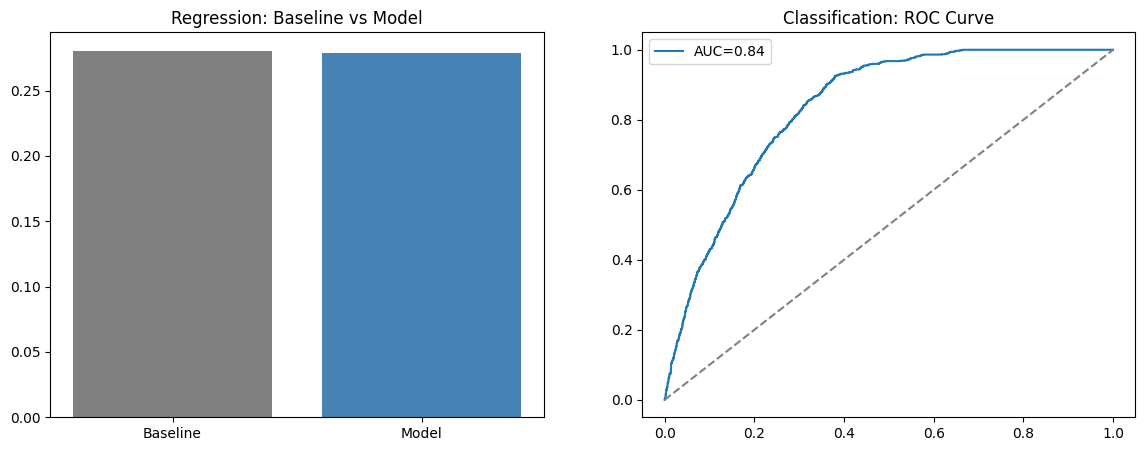

In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].bar(['Baseline','Model'], [baseline_mae, model_mae], color=['gray','steelblue'])
axes[0].set_title('Regression: Baseline vs Model')
fpr, tpr, _ = roc_curve(y_test_c, clf_probs)
axes[1].plot(fpr, tpr, label=f'AUC={roc_auc_score(y_test_c, clf_probs):.2f}')
axes[1].plot([0,1],[0,1],'--',color='gray')
axes[1].set_title('Classification: ROC Curve')
axes[1].legend()
plt.savefig('results_charts.png', dpi=150)
plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.